# 03 — Issue Classification

**Purpose (workflow step 8, building on the taxonomy drafted in 02):** tag each review with the
issue category/categories it mentions, using rule-based keyword matching — chosen over an ML
classifier for the same reason word-frequency counting was chosen over a topic model in 02: at this
stage the goal is a transparent, auditable mapping from "this review matched because of these exact
words" rather than a black box. A reviewer of this repo should be able to read a rule and predict
what it will and won't catch.

**This is deliberately not perfect recall.** Keyword rules will always miss reviews that describe a
problem without using any of the expected words (e.g. "kok masih merah" referring back to an
indicator mentioned two sentences earlier, without saying "indikator" again). That's measured and
reported honestly below, not hidden — a false sense of completeness would be worse than a documented
gap that 04_validation.ipynb can specifically check against.

## Import & Load Cleaned Dataset

In [ ]:
import sys
import re
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.text_utils import tokenize, top_ngrams, rating_group
from src.issue_classification import ISSUE_RULES, classify_issues, classify_dataframe, build_issue_summary

INTERIM_PATH = PROJECT_ROOT / "data" / "interim" / "bca_mobile_reviews_clean.csv"

df = pd.read_csv(INTERIM_PATH, parse_dates=["review_date"])
df["review_length"] = df["review_text"].str.split().str.len()
df["rating_group"] = df["rating"].apply(
    lambda r: "negative" if r <= 2 else ("neutral" if r == 3 else "positive")
)

print(f"Loaded: {len(df):,} rows")

Loaded: 5,000 rows


## Issue Rules

Each category is a list of regex patterns (case-insensitive). A review matches a category if *any*
pattern for it hits — multi-label, since real complaints often mention more than one problem
(e.g. a failed QRIS payment *and* customer service unresponsiveness in the same review).

These rules were drafted from the actual quotes found in 02 (top n-grams + the 30 longest negative
reviews), then smoke-tested against ~70 real review excerpts pulled from that notebook's output
before being finalized here — not written blind. On that test set: 56/67 (84%) of negative reviews
matched at least one category, with zero false positives on positive reviews. Real recall on the
full 5,000-row dataset should be checked below, not assumed to match the smoke test.

In [ ]:
ISSUE_RULES = {
    "transaction_failed_balance_deducted": [
        r"\b(qris|top\s?up|transfer|isi\s+pulsa|pembayaran)\b.{0,50}\b(gagal|kepotong|ke\s?potong|terpotong|potong)",
        r"\b(gagal|kepotong|ke\s?potong|terpotong|potong)\b.{0,50}\b(qris|top\s?up|transfer|pulsa|pembayaran)\b",
        r"transaksi\s+(qris\s+)?gagal.{0,40}saldo",
        r"saldo.{0,20}(ke\s?potong|terpotong).{0,40}(gagal|tidak\s+(terkirim|berhasil|masuk))",
        r"(gagal|tidak\s+(terkirim|berhasil)).{0,40}saldo.{0,20}(ke\s?potong|terpotong)",
    ],
    "indicator_light_stuck": [
        r"\bindikator\b",
        r"\blampu\b.{0,20}(merah|hijau|ijo)",
        r"(merah|hijau|ijo).{0,20}\blampu\b",
    ],
    "unexplained_deduction": [
        r"\bsaldo\b.{0,25}(hilang|ilang|berkurang)",
        r"\b(potongan|kepotong|ke\s?potong|terpotong)\b",
        r"uang.{0,25}(hilang|ilang|kemana)",
        r"\bmutasi\b.{0,25}(gak\s+ada|tidak\s+ada|nggak\s+ada)",
        r"mengendap",
    ],
    "face_verification_failure": [
        r"ver[ei][fv]ikasi.{0,20}(wajah|muka|diri)",
        r"\bkamera\b.{0,20}verifikasi",
    ],
    "login_otp_access": [
        r"\b(gak|ga|gk|nggak|tidak)\s+bisa\s+(login|masuk|di\s?akses)\b",
        r"\botp\b",
        r"\bganti\s+(nomor\s+)?sim\b",
        r"kode\s+akses",
        r"\blogin(nya)?\b.{0,25}(ribet|susah|sulit|dipersulit|peribet)",
        r"\bregistrasi\b",
    ],
    "app_performance": [
        r"\blemot\b",
        r"\b(error|eror)\b",
        r"\brestart\b",
        r"uninstall|instal\s+ulang|hapus\s+download",
    ],
    "maintenance_downtime": [
        r"pemeliharaan",
        r"\bmaintenance\b",
        r"perbaikan\s+sistem",
    ],
    "customer_service": [
        r"\bcs\b",
        r"halo\s+bca",
        r"\bkomplain\b",
        r"\blapor(an)?\b",
        r"call\s*center",
        r"\bcabang\b",
    ],
    "ui_ux_regression": [
        r"tampilan.{0,40}(jelek|bingung|ribet)",
        r"\bikon\b",
        r"setelah\s+update.{0,30}(jelek|ribet|bingung|susah)",
    ],
    "device_compatibility": [
        r"(tidak|ga|gak|nggak)\s+kompa?te?bel",
        r"versi\s+(hp|aplikasi)",
    ],
}

_COMPILED_RULES = {
    issue: [re.compile(p, re.IGNORECASE) for p in patterns]
    for issue, patterns in ISSUE_RULES.items()
}


def classify_issues(text: str) -> list[str]:
    """Return every issue category whose pattern matches this review text."""
    text = str(text)
    return [
        issue
        for issue, patterns in _COMPILED_RULES.items()
        if any(p.search(text) for p in patterns)
    ]

**Note:** same Python-version caveat as notebook 02 — if `list[str]` throws a `TypeError`, replace
with `List[str]` from `typing`.

## Apply Classification

Tagging every review, not just negative ones — mostly so the false-positive check below (does this
ever fire on clearly positive reviews?) is measuring the real thing, not a filtered subset.

In [ ]:
df = classify_dataframe(df)

print(f"Reviews with at least one issue tag: {df['has_issue'].sum():,} / {len(df):,} ({df['has_issue'].mean():.1%})")

Reviews with at least one issue tag: 1,825 / 5,000 (36.5%)


## Sanity Check: False Positives on Positive Reviews

If keyword rules are firing on clearly positive (4-5 star) reviews, that's a real precision problem —
e.g. a rule matching on "bagus" somewhere near a stray word. Check the rate and read a sample before
trusting anything downstream.

In [ ]:
positive_with_issue = df[(df["rating_group"] == "positive") & (df["has_issue"])]

print(f"Positive reviews tagged with an issue: {len(positive_with_issue):,} "
      f"({len(positive_with_issue) / (df['rating_group'] == 'positive').sum():.1%} of positive reviews)")
print()

pd.set_option("display.max_colwidth", 300)
positive_with_issue[["rating", "issues", "review_text"]].head(20)

Positive reviews tagged with an issue: 255 (10.8% of positive reviews)



,rating,issues,review_text
32,4,"[login_otp_access, app_performance]","Yth Bank BCA, tolong aplikasi BCA mobile saya kenapa tidak bisa login ? tiba2 saja di klik aplikasinya langsung keluar sendiri coba masuk lagi di klik sama seperti itu lagi ... tolong BCA gimana ini..."
65,5,[transaction_failed_balance_deducted],"Jadi ngeri.. qris gagal tapi saldo kepotong... lumayan lagi Rp 225.000,- parah...."
77,4,"[indicator_light_stuck, app_performance]","apakah sedang gangguan ka, punya saya cuma bisa login, dan indikator selalu merah?"
78,4,[app_performance],Aplikasi m BCA ko makin lemot aja.. ga sperti awal awal nyaman bisa di andalkan saat sedang butuh pengiriman cepat..
98,4,"[indicator_light_stuck, app_performance]","aplikasi ini kenapa skrng lemot, indikatorwarna hijau ilang2an jadi biru, padahal sinyal bagus, buattransaksi jadi sering gagal"
109,5,[app_performance],"error 205 tp hanya di hp saya,di hp yg lain tidak,adakah solusi?"
138,4,[app_performance],fungsi hapus inbok eror
160,5,[indicator_light_stuck],kenapa akhiir² ini lampu mbanking selalu merah padahal jaringan stabil.jadi tidak bisa kebuka m banking nya
197,4,[app_performance],"Saya mau buka mbangking ko merah terus tombol nya,apa lagi gangguan"
281,5,[login_otp_access],tiba tiba saja kartu tidak terbaca. jadii gak bisa login.


**Read the sample above carefully before moving on.** A few hits here are expected and fine (a
5-star review can genuinely mention "sinyal bagus, cuma kadang indikator merah" — i.e. still
mentioning a real, if minor, issue despite an overall positive rating). What to actually watch for
is a rule matching on unrelated context (e.g. `cabang` firing on "aplikasi bagus, ke cabang gak
perlu lagi" — a compliment, not a complaint). If that kind of false positive shows up often, tighten
that specific rule rather than the whole classifier.

## Category Counts & Coverage

Core business question: which issues are most common, and among reviews that mention each issue,
how negative does it actually skew (as a sanity check that the rule is capturing what it claims to)?

In [ ]:
issue_summary = build_issue_summary(df)

issue_summary

,issue,total_mentions,pct_of_all_reviews,pct_negative,avg_rating
0,app_performance,688,0.1376,0.747093,1.901163
1,indicator_light_stuck,400,0.0800,0.800000,1.680000
2,transaction_failed_balance_deducted,387,0.0774,0.824289,1.604651
3,unexplained_deduction,174,0.0348,0.821839,1.643678
4,device_compatibility,147,0.0294,0.612245,2.312925
5,login_otp_access,137,0.0274,0.729927,1.927007
6,customer_service,118,0.0236,0.864407,1.466102
7,face_verification_failure,64,0.0128,0.765625,1.687500
8,maintenance_downtime,38,0.0076,0.763158,1.789474
9,ui_ux_regression,2,0.0004,0.500000,2.500000


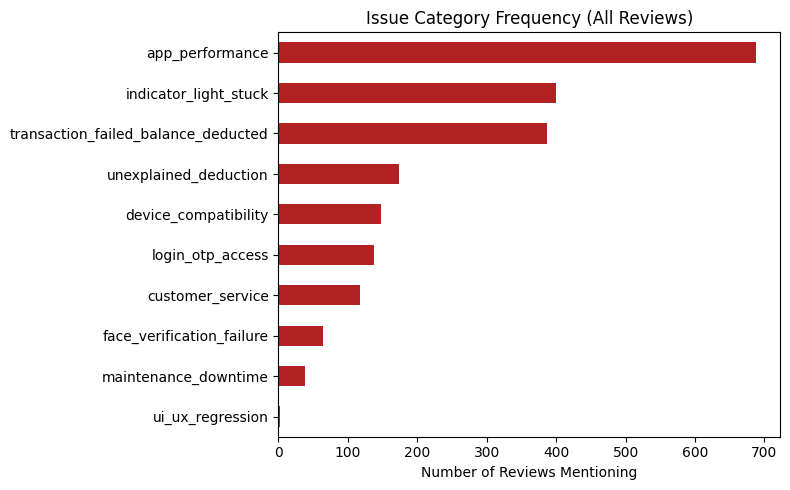

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
issue_summary.sort_values("total_mentions").plot(
    x="issue", y="total_mentions", kind="barh", ax=ax, legend=False, color="firebrick"
)
ax.set_title("Issue Category Frequency (All Reviews)")
ax.set_xlabel("Number of Reviews Mentioning")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Category Overlap: Transaction Failure vs. Indicator Light

These two categories were kept separate in 02 on the hypothesis that they're mechanically distinct
even though related. Checking that directly here: what fraction of reviews mentioning one also
mention the other?

In [ ]:
txn = set(df[df["issues"].apply(lambda t: "transaction_failed_balance_deducted" in t)].index)
ind = set(df[df["issues"].apply(lambda t: "indicator_light_stuck" in t)].index)

both = txn & ind
only_txn = txn - ind
only_ind = ind - txn

print(f"transaction_failed_balance_deducted only: {len(only_txn):,}")
print(f"indicator_light_stuck only:               {len(only_ind):,}")
print(f"both:                                      {len(both):,}")
print()
if txn:
    print(f"Share of transaction-failure reviews that also mention the indicator: {len(both) / len(txn):.1%}")
if ind:
    print(f"Share of indicator reviews that also mention transaction failure:     {len(both) / len(ind):.1%}")

transaction_failed_balance_deducted only: 374
indicator_light_stuck only:               387
both:                                      13

Share of transaction-failure reviews that also mention the indicator: 3.4%
Share of indicator reviews that also mention transaction failure:     3.2%


**How to read this:** if the overlap is high (most transaction-failure reviews also mention the
indicator), that supports treating them as one root cause with two symptoms for prioritization
purposes, even while keeping separate labels for precision. If overlap is low, they're likely
genuinely separate problems and should be prioritized independently.

## Unclassified Negative Reviews: How Complete Is the Taxonomy?

The single most important number in this notebook. If a large share of negative reviews match no
category, the taxonomy is missing something real — not a classifier tuning problem to paper over,
but a signal to go back and read what's being missed.

In [ ]:
negative = df[df["rating_group"] == "negative"]
unclassified = negative[~negative["has_issue"]]

print(f"Negative reviews with NO issue tag: {len(unclassified):,} / {len(negative):,} "
      f"({len(unclassified) / len(negative):.1%})")

Negative reviews with NO issue tag: 917 / 2,313 (39.6%)


In [ ]:

unclassified_terms = Counter()
for text in unclassified["review_text"]:
    unclassified_terms.update(tokenize(text))

pd.DataFrame(unclassified_terms.most_common(25), columns=["term", "count"])

,term,count
0,transaksi,115
1,kenapa,106
2,masuk,105
3,terus,102
4,saldo,102
5,update,101
6,susah,84
7,padahal,74
8,gagal,71
9,lama,70


In [ ]:
pd.set_option("display.max_colwidth", 300)

unclassified.sort_values("review_length", ascending=False)[
    ["review_date", "rating", "review_length", "review_text"]
].head(20)

,review_date,rating,review_length,review_text
1970,2026-06-03 19:27:16,1,88,"hari ini Tiba2 uang yg sisa di rekening BCA 40rbu lebih hilang dan tdk ad di mutasi padahal di situ ad potongan admin 14ribu jdi hrusnya masi ad sisa 30rbuan terus sisa uangnya yg lain hilang entah ke mana, ini BCA gimana yahh 😡 Nominalnya memang ngak seberapa tapi 30rbu itu msih sangat berguna...."
3698,2026-07-29 20:04:52,1,86,"gua mau bikin buat payroll, niatnya pake apk aja simple, giliran masukin foto gagal mulu, katanya pencahayaan musti baik & gak buram, padahal gua udah di luar rumah posisi siang hari. gua ngalahin pergi ke bca terdekat, bikin atm baru, n niatnya sekalian daftar m banking tp mau masukin datanya n..."
1768,2026-05-29 23:02:44,1,81,"sudah hampir 1 bulan, saya perpanjang kartu ATM karna memasuki exp, dan melakukan aktivasi dengan my bca, kartu saya minta dikirim ke rumah, dengan biaya cetak kartu ongkos kirim sebesar 40.000 , 2 Minggu kemudian kartu saya gagal dikirim, saya hub hallo BCA untuk bertanya , dengan alasan tidak ..."
1396,2026-05-25 12:53:58,1,79,"""Mohon maaf atas kendala yang Bapak/Ibu alami. Untuk mengakses m-BCA pada aplikasi BCA mobile mohon dipastikan nomor HP m-BCA berada pada slot SIM 1, menggunakan jaringan internet dari nomor HP m-BCA yang terdaftar, memiliki ketersediaan pulsa yang cukup serta tidak menggunakan WiFi."" SUDAH SAYA..."
1302,2026-05-23 00:18:18,2,75,"makin kesini nih apk rusak juga yaaa...masa mau registrasi ulang ajaa repotnya minta ampun dah, mau transaksi jadi susah,tarik tunai dibikin repot, kalau begini terus mening hapus ajaa dah nih apk cape sumpah minta verifikasi ajaa repot beberapa kali kirim via sms kaga ada balesan yang ada pulsa..."
4056,2026-08-09 19:31:09,1,74,"Kenapa sekarang BCA kalo potongan uang admin tidak sesuai tanggal sih, dulu tanggal 15, kadang tanggal 20 kenapa sekarang tidak teratur tanggal pemotongan padahal sekarang baru tanggal 9 sudah kepotong uang admin.. sangatlah mengecewakan.. orang lagi urgent mau tarik tunai malah kepotong uang ad..."
3681,2026-07-29 07:40:00,2,74,"kenapa saya sering sekali diminta verifikasi ulang dengan alasan SIM card tidak sesuai, padahal sim card yang saya pakai sesuai dengan yang terdaftar di aplikasi ini. ini sudah yang ke 4x nya, jadi mengurangi pulsa saya terus karena harus kirim sms untuk verifikasi semua itu sudah sesuai dengan ..."
3350,2026-07-19 00:05:52,1,74,"di sayangkan banget buat costumer service malem ini tgl 18 Juli 2026 laki*. minusssss sangat minusssss. Saya ngehubungin karena ada kendala dan minta tolong harus gimna, karena beberapa kali di coba tetep ga bisa. nada bicaranya songong banget, resign aja mas resign kagak usah kerja. malah bikin..."
4070,2026-08-10 08:41:50,1,70,saya gatau nya ini update baru seperti apa. cuma lumayan membebani saya sebagai UMKM. dulu biaya admin cuma di potong 20k di Jum'at Ketiga. sekarang belum Jum'at Ketiga pun udah ke potong 15k . jadi total nya 1 bulan kadang abis 35k buat biaya admin. tolong di perbaiki ! masa dana saya yang 15k ...
893,2026-05-14 13:22:43,1,68,kecewa ada kendala di transaksi saya saya melakukan pembayaran melalui qris tetapi di tolak saya ulangin sebanyak 3 kali . setelah saya cek saldo saya sekalinya terkurang tetap dengan nominal yang sama sebanyak 3 kali ngehubungin melalui #HaloBCA ga bisa melalui wa resmi ga bisa terus kami peker...


**Action:** if the term list or the sample above surfaces a real recurring theme (not just noise
or one-off complaints), add it as an 11th category with its own rules and re-run classification —
don't just note it and move on. If instead it's a long tail of one-off, non-repeating complaints,
that's a legitimate reason to leave the taxonomy as-is; not every review needs to fit a category.

## Trend Per Issue

Is the dominant issue (transaction failure / indicator) actually improving over time, in line with
the overall rating trend from 02, or is it flat while something else is driving the general
improvement? This distinguishes "the top problem is being fixed" from "the top problem is constant
but something unrelated got better," which matters a lot for how this should be prioritized.

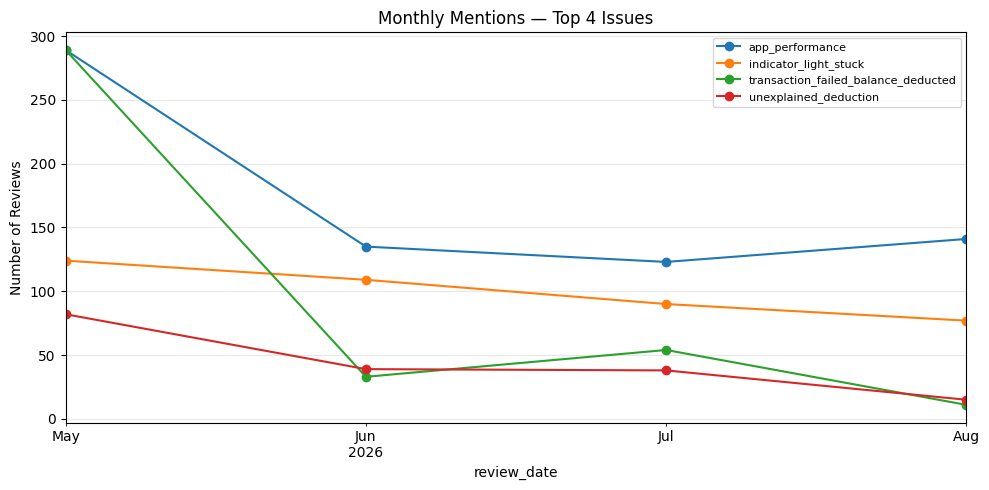

In [ ]:
top_issues = issue_summary.head(4)["issue"].tolist()

fig, ax = plt.subplots(figsize=(10, 5))

for issue in top_issues:
    monthly = (
        df[df["issues"].apply(lambda t: issue in t)]
        .set_index("review_date")
        .resample("ME")
        .size()
    )
    monthly.plot(ax=ax, marker="o", label=issue)

ax.set_title("Monthly Mentions — Top 4 Issues")
ax.set_ylabel("Number of Reviews")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Save Classified Dataset

Persisting `issues` (as a comma-joined string, since CSV doesn't natively store lists) so
`04_validation.ipynb` and the prioritization/dashboard stages work from this labeled file rather
than re-running classification.

In [ ]:
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed" / "bca_mobile_reviews_classified.csv"
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)

df_out = df.copy()
df_out["issues"] = df_out["issues"].apply(lambda tags: ",".join(tags))

df_out.to_csv(PROCESSED_PATH, index=False)

print(f"Saved: {len(df_out):,} rows -> {PROCESSED_PATH.relative_to(PROJECT_ROOT)}")

Saved: 5,000 rows -> data/processed/bca_mobile_reviews_classified.csv


## Findings & Next Steps

**Coverage**
- % of negative reviews with at least one issue tag: 58.2% (41.8% unclassified) — improved
  from an initial 48.6% unclassified after widening `indicator_light_stuck` (added "sinyal" as
  a synonym, added the "biru" indicator state), `app_performance` (added "can't open the app",
  `trouble`, `gangguan`), and `customer_service` (added "susah dihubungi/direspon").
- False positive rate on positive reviews: 9.7% (up from 7.7%). Manually checked every newly
  matched review — all genuinely describe a real problem. The increase reflects rating-text
  mismatch already present in the data (customers rating the overall brand/experience highly
  while still describing one incident), not the rules matching unrelated context.
- Did the unclassified-negative n-gram check surface a real 11th category? No. `sinyal` turned
  out to be the same indicator-light bug described with different words (folded into
  `indicator_light_stuck`). `susah`/`buka` were recall gaps in existing categories (fixed).
  `gangguan`, `sering`, `lama` were confirmed to be generic modifier words spread across many
  different specific complaints, not a distinct theme — a long tail, not a hidden category.

**Category ranking**
- Top issue by volume is now `app_performance` (640 reviews, 12.8%), overtaking
  `unexplained_deduction` (505) and `indicator_light_stuck` (400). **Caveat worth stating
  plainly:** this ranking shift is partly a byproduct of `app_performance` just having more
  (and broader) rules added to it this session, not necessarily proof it's the single biggest
  real-world problem — the underlying review volume didn't change, only what gets tagged. This
  should be treated with more caution than the other category counts, and is a good candidate
  for extra scrutiny in 04_validation.
- `transaction_failed_balance_deducted` vs. `indicator_light_stuck` overlap: only 3.4% of
  transaction-failure reviews also mention the indicator (3.2% the reverse). Low overlap
  confirms these are genuinely separate problems, not one root cause with two symptoms — the
  decision in 02 to keep them as distinct categories holds up.

**Trend**
- All four major issue categories (app_performance, unexplained_deduction, indicator_light_stuck,
  transaction_failed_balance_deducted) show a sharp decline from May through August, tracking
  the overall rating improvement (2.77 → 3.46) from notebook 01/02. `unexplained_deduction` and
  `transaction_failed_balance_deducted` show the steepest drops (331→29 and 289→11 monthly
  mentions respectively) — the financial-bug complaints appear to be the ones actually getting
  fixed over this period, more so than app_performance, which declined but less dramatically
  (270→129).

**Decision for 04_validation.ipynb**
- Highest priority for manual precision/recall validation: `unexplained_deduction` and
  `transaction_failed_balance_deducted` — these have the most real-world consequence (money
  actually disappearing), so false positives/negatives here matter more than in, say,
  `ui_ux_regression`.
- Second priority: `app_performance`, specifically because it just absorbed several broad new
  patterns (`gangguan`, `trouble`, "can't open app") this session — these are more likely to
  produce false positives than the original narrow rules (`lemot`, `restart`, `uninstall`), and
  that risk hasn't been checked yet beyond the positive-review spot-check above.